In [307]:
import pandas as pd

application = pd.read_csv("C:\\Users\\ASUS\\Intelligent-Credit-Risk-System\data\\application_record.csv")
credit = pd.read_csv("C:\\Users\\ASUS\\Intelligent-Credit-Risk-System\\data\\credit_record.csv")

In [308]:
application.info()
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [309]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [310]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [311]:
top_occupations = application['OCCUPATION_TYPE'].value_counts().nlargest(5).index

application['OCCUPATION_TYPE'] = application['OCCUPATION_TYPE'].apply(
    lambda x: x if x in top_occupations else 'Other'
)

In [312]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Other,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [313]:
application['NAME_INCOME_TYPE'].unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

In [314]:
application['AGE'] = (application['DAYS_BIRTH'].abs() / 365).astype(int)

In [315]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Other,2.0,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Other,2.0,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52


In [316]:
application['EMPLOYMENT_YEARS'] = (application['DAYS_EMPLOYED'].replace(365243, 0).abs() / 365).astype(int)

In [317]:
application.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED'], axis=1, inplace=True)

In [318]:
application[['AGE', 'EMPLOYMENT_YEARS']].head()

,AGE,EMPLOYMENT_YEARS
0,32,12
1,32,12
2,58,3
3,52,8
4,52,8


In [319]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Other,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Other,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Other,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8


In [320]:
application.drop('FLAG_MOBIL', axis=1, inplace=True)

In [321]:
application[['FLAG_WORK_PHONE','FLAG_PHONE','FLAG_EMAIL']].nunique()

FLAG_WORK_PHONE    2
FLAG_PHONE         2
FLAG_EMAIL         2
dtype: int64

In [322]:
application = application.drop_duplicates()

In [323]:
application.drop(['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL'], axis=1, inplace=True)

In [324]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Other,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,Other,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,Other,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,Sales staff,1.0,52,8


In [325]:
application[['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_HOUSING_TYPE','OCCUPATION_TYPE','NAME_FAMILY_STATUS']].nunique()

NAME_INCOME_TYPE       5
NAME_EDUCATION_TYPE    5
NAME_HOUSING_TYPE      6
OCCUPATION_TYPE        6
NAME_FAMILY_STATUS     5
dtype: int64

In [326]:
for col in ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_HOUSING_TYPE','OCCUPATION_TYPE','NAME_FAMILY_STATUS']:
    print(f"\n{col}:")
    print(application[col].unique())


NAME_INCOME_TYPE:
['Working' 'Commercial associate' 'Pensioner' 'State servant' 'Student']

NAME_EDUCATION_TYPE:
['Higher education' 'Secondary / secondary special' 'Incomplete higher'
 'Lower secondary' 'Academic degree']

NAME_HOUSING_TYPE:
['Rented apartment' 'House / apartment' 'Municipal apartment'
 'With parents' 'Co-op apartment' 'Office apartment']

OCCUPATION_TYPE:
['Other' 'Sales staff' 'Laborers' 'Managers' 'Drivers' 'Core staff']

NAME_FAMILY_STATUS:
['Civil marriage' 'Married' 'Single / not married' 'Separated' 'Widow']


In [327]:
application['NAME_INCOME_TYPE'] = application['NAME_INCOME_TYPE'].replace({
    'Student': 'Working'
})

application['NAME_EDUCATION_TYPE'] = application['NAME_EDUCATION_TYPE'].replace({
    'Lower secondary': 'Secondary',
    'Incomplete higher': 'Higher',
    'Academic degree': 'Higher'
})

application['NAME_HOUSING_TYPE'] = application['NAME_HOUSING_TYPE'].replace({
    'Rented apartment': 'Apartment',
    'Municipal apartment': 'Apartment',
    'Co-op apartment': 'Apartment',
    'Office apartment': 'Apartment',
    'With parents': 'Other'
})

application['OCCUPATION_TYPE'] = application['OCCUPATION_TYPE'].replace({
    'Drivers': 'Laborers',
    'Core staff': 'Laborers',
    'Managers': 'Other'
})

application['NAME_FAMILY_STATUS'] = application['NAME_FAMILY_STATUS'].replace({
    'Civil marriage': 'Married',
    'Separated': 'Single',
    'Widow': 'Single'
})

In [328]:
for col in ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_HOUSING_TYPE','OCCUPATION_TYPE','NAME_FAMILY_STATUS']:
    print(f"\n{col}:")
    print(application[col].unique())


NAME_INCOME_TYPE:
['Working' 'Commercial associate' 'Pensioner' 'State servant']

NAME_EDUCATION_TYPE:
['Higher education' 'Secondary / secondary special' 'Higher' 'Secondary']

NAME_HOUSING_TYPE:
['Apartment' 'House / apartment' 'Other']

OCCUPATION_TYPE:
['Other' 'Sales staff' 'Laborers']

NAME_FAMILY_STATUS:
['Married' 'Single / not married' 'Single']


In [329]:
application['NAME_EDUCATION_TYPE'] = application['NAME_EDUCATION_TYPE'].replace({
    'Secondary / secondary special': 'Secondary',
    'Lower secondary': 'Secondary',
    'Incomplete higher': 'Higher',
    'Academic degree': 'Higher'
})

application['NAME_FAMILY_STATUS'] = application['NAME_FAMILY_STATUS'].replace({
    'Single / not married': 'Single',
    'Separated': 'Single',
    'Widow': 'Single',
    'Civil marriage': 'Married'
})

In [330]:
for col in ['NAME_INCOME_TYPE','NAME_EDUCATION_TYPE','NAME_HOUSING_TYPE','OCCUPATION_TYPE','NAME_FAMILY_STATUS']:
    print(f"\n{col}:")
    print(application[col].unique())


NAME_INCOME_TYPE:
['Working' 'Commercial associate' 'Pensioner' 'State servant']

NAME_EDUCATION_TYPE:
['Higher education' 'Secondary' 'Higher']

NAME_HOUSING_TYPE:
['Apartment' 'House / apartment' 'Other']

OCCUPATION_TYPE:
['Other' 'Sales staff' 'Laborers']

NAME_FAMILY_STATUS:
['Married' 'Single']


In [331]:
application['NAME_INCOME_TYPE'] = application['NAME_INCOME_TYPE'].replace({
    'Commercial associate': 'Working',
    'State servant': 'Working'
})

In [332]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,Other,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,Other,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary,Married,House / apartment,Other,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,Sales staff,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,Sales staff,1.0,52,8


In [333]:
application.drop('OCCUPATION_TYPE', axis=1, inplace=True)

In [334]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,2.0,32,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,2.0,32,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary,Married,House / apartment,2.0,58,3
3,5008808,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,1.0,52,8
4,5008809,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,1.0,52,8


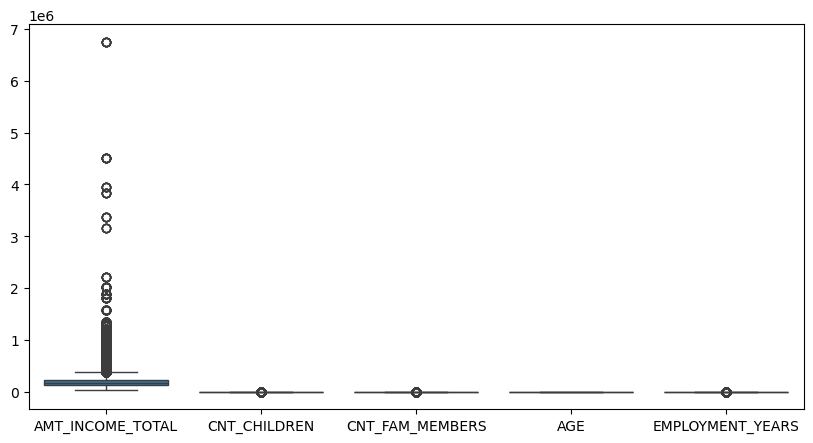

In [335]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=application[['AMT_INCOME_TOTAL','CNT_CHILDREN','CNT_FAM_MEMBERS','AGE','EMPLOYMENT_YEARS']])
plt.show()

In [336]:
upper_limit = application['AMT_INCOME_TOTAL'].quantile(0.99)

application['AMT_INCOME_TOTAL'] = application['AMT_INCOME_TOTAL'].clip(upper=upper_limit)

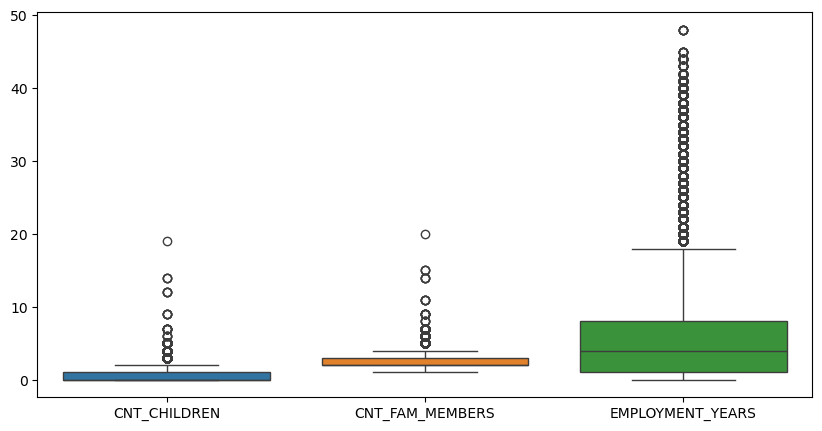

In [337]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=application[['CNT_CHILDREN','CNT_FAM_MEMBERS','EMPLOYMENT_YEARS']])
plt.show()

In [338]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [339]:
application = application[
    (application['CNT_CHILDREN'] <= 5) &
    (application['CNT_FAM_MEMBERS'] <= 8)
]

In [340]:
upper_limit = application['EMPLOYMENT_YEARS'].quantile(0.99)
application['EMPLOYMENT_YEARS'] = application['EMPLOYMENT_YEARS'].clip(upper=upper_limit)

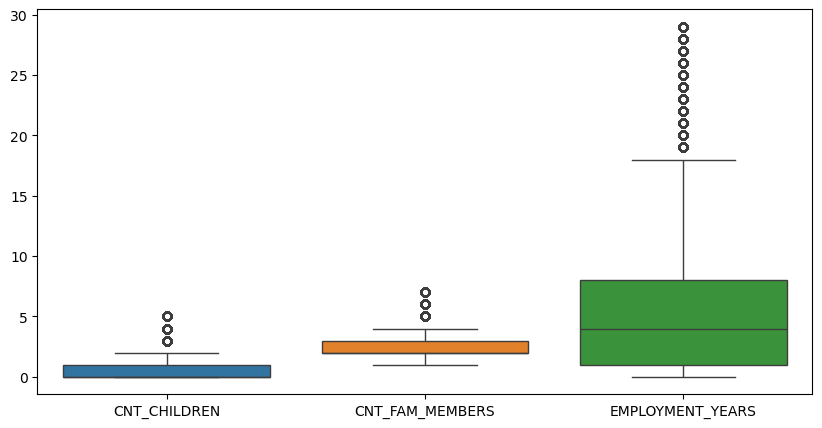

In [341]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=application[['CNT_CHILDREN','CNT_FAM_MEMBERS','EMPLOYMENT_YEARS']])
plt.show()

In [342]:
credit['STATUS'] = credit['STATUS'].replace({'X': -1, 'C': -1}).astype(int)

In [343]:
target = credit.groupby('ID')['STATUS'].max().apply(lambda x: 1 if x >= 3 else 0)

In [344]:
application = application.merge(target, on='ID', how='inner')

In [345]:
credit['STATUS'] = credit['STATUS'].replace({'X': -1, 'C': -1}).astype(int)

In [346]:
print(target.head())

ID
5001711    0
5001712    0
5001713    0
5001714    0
5001715    0
Name: STATUS, dtype: int64


In [347]:
target = target.reset_index()
target.columns = ['ID', 'TARGET']

In [348]:
target = credit.groupby('ID')['STATUS'].max().reset_index()
target['TARGET'] = target['STATUS'].apply(lambda x: 1 if x >= 3 else 0)

target = target[['ID', 'TARGET']]

In [349]:
application = application.merge(target, on='ID', how='inner')

In [350]:
application['TARGET'].value_counts()

TARGET
0    36149
1      302
Name: count, dtype: int64

In [351]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS,STATUS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,2.0,32,12,0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Married,Apartment,2.0,32,12,0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary,Married,House / apartment,2.0,58,3,0,0
3,5008808,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,1.0,52,8,0,0
4,5008809,F,N,Y,0,270000.0,Working,Secondary,Single,House / apartment,1.0,52,8,0,0


In [352]:
application = pd.get_dummies(application, drop_first=True)

In [353]:
application.head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS,STATUS,TARGET,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary,NAME_FAMILY_STATUS_Single,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Other
0,5008804,0,427500.0,2.0,32,12,0,0,True,True,True,True,True,False,False,False,False
1,5008805,0,427500.0,2.0,32,12,0,0,True,True,True,True,True,False,False,False,False
2,5008806,0,112500.0,2.0,58,3,0,0,True,True,True,True,False,True,False,True,False
3,5008808,0,270000.0,1.0,52,8,0,0,False,False,True,True,False,True,True,True,False
4,5008809,0,270000.0,1.0,52,8,0,0,False,False,True,True,False,True,True,True,False


In [354]:
application = application.astype(int)

In [355]:
application.dtypes

ID                                      int64
CNT_CHILDREN                            int64
AMT_INCOME_TOTAL                        int64
CNT_FAM_MEMBERS                         int64
AGE                                     int64
EMPLOYMENT_YEARS                        int64
STATUS                                  int64
TARGET                                  int64
CODE_GENDER_M                           int64
FLAG_OWN_CAR_Y                          int64
FLAG_OWN_REALTY_Y                       int64
NAME_INCOME_TYPE_Working                int64
NAME_EDUCATION_TYPE_Higher education    int64
NAME_EDUCATION_TYPE_Secondary           int64
NAME_FAMILY_STATUS_Single               int64
NAME_HOUSING_TYPE_House / apartment     int64
NAME_HOUSING_TYPE_Other                 int64
dtype: object

In [356]:
application.head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS,STATUS,TARGET,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary,NAME_FAMILY_STATUS_Single,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Other
0,5008804,0,427500,2,32,12,0,0,1,1,1,1,1,0,0,0,0
1,5008805,0,427500,2,32,12,0,0,1,1,1,1,1,0,0,0,0
2,5008806,0,112500,2,58,3,0,0,1,1,1,1,0,1,0,1,0
3,5008808,0,270000,1,52,8,0,0,0,0,1,1,0,1,1,1,0
4,5008809,0,270000,1,52,8,0,0,0,0,1,1,0,1,1,1,0


In [357]:
application.shape

(36451, 17)

In [358]:
import numpy as np

application['AMT_INCOME_TOTAL'] = np.log1p(application['AMT_INCOME_TOTAL'])

In [359]:
application.head()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,AGE,EMPLOYMENT_YEARS,STATUS,TARGET,CODE_GENDER_M,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Secondary,NAME_FAMILY_STATUS_Single,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Other
0,5008804,0,12.965712,2,32,12,0,0,1,1,1,1,1,0,0,0,0
1,5008805,0,12.965712,2,32,12,0,0,1,1,1,1,1,0,0,0,0
2,5008806,0,11.630717,2,58,3,0,0,1,1,1,1,0,1,0,1,0
3,5008808,0,12.506181,1,52,8,0,0,0,0,1,1,0,1,1,1,0
4,5008809,0,12.506181,1,52,8,0,0,0,0,1,1,0,1,1,1,0


In [360]:
application.drop(['ID', 'STATUS'], axis=1, inplace=True)

In [361]:
from sklearn.model_selection import train_test_split

X = application.drop('TARGET', axis=1)
y = application['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [362]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [363]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_sm, y_train_sm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [364]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [365]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6915  316]
 [  43   17]]
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      7231
           1       0.05      0.28      0.09        60

    accuracy                           0.95      7291
   macro avg       0.52      0.62      0.53      7291
weighted avg       0.99      0.95      0.97      7291



In [366]:
threshold = 0.3

y_pred_new = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[6312  919]
 [  40   20]]
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      7231
           1       0.02      0.33      0.04        60

    accuracy                           0.87      7291
   macro avg       0.51      0.60      0.48      7291
weighted avg       0.99      0.87      0.92      7291



In [367]:
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)   # ⚠️ IMPORTANT: SMOTE nahi use karna ab

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [368]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [369]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6786  445]
 [  30   30]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      7231
           1       0.06      0.50      0.11        60

    accuracy                           0.93      7291
   macro avg       0.53      0.72      0.54      7291
weighted avg       0.99      0.93      0.96      7291



In [370]:
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred_new = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[6003 1228]
 [  26   34]]
              precision    recall  f1-score   support

           0       1.00      0.83      0.91      7231
           1       0.03      0.57      0.05        60

    accuracy                           0.83      7291
   macro avg       0.51      0.70      0.48      7291
weighted avg       0.99      0.83      0.90      7291



In [371]:
threshold = 0.2
y_pred_new = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[5182 2049]
 [  23   37]]
              precision    recall  f1-score   support

           0       1.00      0.72      0.83      7231
           1       0.02      0.62      0.03        60

    accuracy                           0.72      7291
   macro avg       0.51      0.67      0.43      7291
weighted avg       0.99      0.72      0.83      7291



In [372]:
threshold = 0.15
y_pred_new = (y_prob > threshold).astype(int)

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[4612 2619]
 [  19   41]]
              precision    recall  f1-score   support

           0       1.00      0.64      0.78      7231
           1       0.02      0.68      0.03        60

    accuracy                           0.64      7291
   macro avg       0.51      0.66      0.40      7291
weighted avg       0.99      0.64      0.77      7291



In [373]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Step 1: scale_pos_weight calculate
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Step 2: parameter grid (light + safe)
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05],
    'scale_pos_weight': [scale]
}

# Step 3: model
model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Step 4: GridSearch (IMPORTANT FIX: n_jobs=1)
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=1,      # 🔥 fixed (no crash)
    verbose=1
)

# Step 5: fit
grid.fit(X_train, y_train)

# Step 6: best params
print("Best Parameters:", grid.best_params_)

# Step 7: best model
best_model = grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'scale_pos_weight': 119.49586776859505}


In [374]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6105 1126]
 [  25   35]]
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      7231
           1       0.03      0.58      0.06        60

    accuracy                           0.84      7291
   macro avg       0.51      0.71      0.49      7291
weighted avg       0.99      0.84      0.91      7291



In [375]:
threshold = 0.43

y_pred_final = (y_prob > threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[5367 1864]
 [  18   42]]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      7231
           1       0.02      0.70      0.04        60

    accuracy                           0.74      7291
   macro avg       0.51      0.72      0.45      7291
weighted avg       0.99      0.74      0.84      7291



In [376]:
from sklearn.metrics import confusion_matrix, classification_report
import os, joblib, json

# ── Verify ─────────────────────────────────────────────────
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.43).astype(int)
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ── Save ───────────────────────────────────────────────────
save_dir = r"C:\Users\ASUS\Intelligent-Credit-Risk-System\models"
os.makedirs(save_dir, exist_ok=True)
best_model.save_model(os.path.join(save_dir, "credit_card_model.json"))
joblib.dump(list(X.columns), os.path.join(save_dir, "credit_card_features.pkl"))
with open(os.path.join(save_dir, "credit_card_threshold.json"), "w") as f:
    json.dump({"threshold": 0.43}, f)

print("\n✅ credit_card_model.json saved!")
print("✅ credit_card_features.pkl saved!")
print("✅ credit_card_threshold.json saved!")

📊 Confusion Matrix:
[[5367 1864]
 [  18   42]]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85      7231
           1       0.02      0.70      0.04        60

    accuracy                           0.74      7291
   macro avg       0.51      0.72      0.45      7291
weighted avg       0.99      0.74      0.84      7291


✅ credit_card_model.json saved!
✅ credit_card_features.pkl saved!
✅ credit_card_threshold.json saved!


In [377]:
from sklearn.metrics import confusion_matrix

for threshold in [0.1, 0.15, 0.2, 0.25, 0.3]:
    y_pred = (y_prob > threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Threshold {threshold}: {cm[1]}")

Threshold 0.1: [ 5 55]
Threshold 0.15: [ 7 53]
Threshold 0.2: [10 50]
Threshold 0.25: [12 48]
Threshold 0.3: [14 46]


In [378]:
import os, joblib, json
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = application.drop('TARGET', axis=1)
y = application['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Simple model — GridSearch nahi
model_final = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale, random_state=42, eval_metric='logloss')
model_final.fit(X_train, y_train)

y_prob = model_final.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.40).astype(int)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save
save_dir = r"C:\Users\ASUS\Intelligent-Credit-Risk-System\models"
os.makedirs(save_dir, exist_ok=True)
model_final.save_model(os.path.join(save_dir, "credit_card_model.json"))
joblib.dump(list(X.columns), os.path.join(save_dir, "credit_card_features.pkl"))
with open(os.path.join(save_dir, "credit_card_threshold.json"), "w") as f:
    json.dump({"threshold": 0.43}, f)

print("✅ Saved!")

[[6471  760]
 [  29   31]]
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      7231
           1       0.04      0.52      0.07        60

    accuracy                           0.89      7291
   macro avg       0.52      0.71      0.51      7291
weighted avg       0.99      0.89      0.94      7291

✅ Saved!


In [390]:
import pandas as pd
import numpy as np
import os, joblib, json
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ── Fresh data load ────────────────────────────────────────
app = pd.read_csv(r"C:\Users\ASUS\Intelligent-Credit-Risk-System\data\application_record.csv")
cred = pd.read_csv(r"C:\Users\ASUS\Intelligent-Credit-Risk-System\data\credit_record.csv")

# ── Preprocessing ──────────────────────────────────────────
top_occ = app['OCCUPATION_TYPE'].value_counts().nlargest(5).index
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].apply(lambda x: x if x in top_occ else 'Other')
app['AGE'] = (app['DAYS_BIRTH'].abs() / 365).astype(int)
app['EMPLOYMENT_YEARS'] = (app['DAYS_EMPLOYED'].replace(365243, 0).abs() / 365).astype(int)
app.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL',
          'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL'], axis=1, inplace=True)
app = app.drop_duplicates()

app['NAME_INCOME_TYPE'] = app['NAME_INCOME_TYPE'].replace(
    {'Student': 'Working', 'Commercial associate': 'Working', 'State servant': 'Working'})
app['NAME_EDUCATION_TYPE'] = app['NAME_EDUCATION_TYPE'].replace(
    {'Lower secondary': 'Secondary', 'Secondary / secondary special': 'Secondary',
     'Incomplete higher': 'Higher', 'Academic degree': 'Higher'})
app['NAME_HOUSING_TYPE'] = app['NAME_HOUSING_TYPE'].replace(
    {'Rented apartment': 'Apartment', 'Municipal apartment': 'Apartment',
     'Co-op apartment': 'Apartment', 'Office apartment': 'Apartment', 'With parents': 'Other'})
app['NAME_FAMILY_STATUS'] = app['NAME_FAMILY_STATUS'].replace(
    {'Civil marriage': 'Married', 'Single / not married': 'Single',
     'Separated': 'Single', 'Widow': 'Single'})
app['OCCUPATION_TYPE'] = app['OCCUPATION_TYPE'].replace(
    {'Drivers': 'Laborers', 'Core staff': 'Laborers', 'Managers': 'Other'})
app = app[(app['CNT_CHILDREN'] <= 5) & (app['CNT_FAM_MEMBERS'] <= 8)]
app['AMT_INCOME_TOTAL'] = app['AMT_INCOME_TOTAL'].clip(upper=app['AMT_INCOME_TOTAL'].quantile(0.99))
app['EMPLOYMENT_YEARS'] = app['EMPLOYMENT_YEARS'].clip(upper=app['EMPLOYMENT_YEARS'].quantile(0.99))
app.drop('OCCUPATION_TYPE', axis=1, inplace=True)

# ── Target ─────────────────────────────────────────────────
cred['STATUS'] = cred['STATUS'].replace({'X': -1, 'C': -1}).astype(int)
target = cred.groupby('ID')['STATUS'].max().reset_index()
target['TARGET'] = target['STATUS'].apply(lambda x: 1 if x >= 3 else 0)
target = target[['ID', 'TARGET']]
app = app.merge(target, on='ID', how='inner')

# ── Encoding ───────────────────────────────────────────────
app = pd.get_dummies(app, drop_first=True)
app = app.astype(int)
app['AMT_INCOME_TOTAL'] = np.log1p(app['AMT_INCOME_TOTAL'])
app.drop(['ID'], axis=1, inplace=True)

# ── Train ──────────────────────────────────────────────────
X = app.drop('TARGET', axis=1)
y = app['TARGET']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
model_final = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale, random_state=42, eval_metric='logloss')
model_final.fit(X_train, y_train)

# ── Verify ─────────────────────────────────────────────────
y_prob = model_final.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.20456).astype(int)
print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ── Save ───────────────────────────────────────────────────
save_dir = r"C:\Users\ASUS\Intelligent-Credit-Risk-System\models"
os.makedirs(save_dir, exist_ok=True)
model_final.save_model(os.path.join(save_dir, "credit_card_model.json"))
joblib.dump(list(X.columns), os.path.join(save_dir, "credit_card_features.pkl"))
with open(os.path.join(save_dir, "credit_card_threshold.json"), "w") as f:
    json.dump({"threshold": 0.43}, f)
print("\n✅ Saved!")

📊 Confusion Matrix:
[[5230 2001]
 [  23   37]]
              precision    recall  f1-score   support

           0       1.00      0.72      0.84      7231
           1       0.02      0.62      0.04        60

    accuracy                           0.72      7291
   macro avg       0.51      0.67      0.44      7291
weighted avg       0.99      0.72      0.83      7291


✅ Saved!
